## Load Modeling Dataset

This notebook loads the final modeling-ready dataset created in Notebook 02. The dataset contains three selected predictor features and one binary target variable indicating whether a hospital-measure record has an excess readmission ratio above 1.0.

In [29]:
#Import Pandas for loading data
import pandas as pd

#Load processed data with the input columns and target
df_model_ready = pd.read_parquet('../data/processed/df_model_ready.parquet')

# Confirm dataset dimension after loading
df_model_ready.shape

(8037, 4)

In [30]:
df_model_ready.head()

#Confirm dataset dtypes before modeling
df_model_ready.dtypes

#Confirm that there are no NA values
#df_model_ready.isna().sum()

state                          str
measure_name                   str
number_of_discharges       float64
high_excess_readmission      int64
dtype: object

## Train-Test Split

Before training the classification model, the dataset was separated into predictor variables (`X`) and the binary target variable (`y`). The dataset was then split into training and testing subsets using an 80/20 split.

Stratification was applied to preserve the target class distribution across both subsets. This helps ensure that the training and testing data maintain similar proportions of high and non-high excess readmission records.

The train-test split was performed before preprocessing to avoid data leakage from the testing data into the training workflow.

In [31]:
from sklearn.model_selection import train_test_split

X = df_model_ready[['state', 'measure_name', 'number_of_discharges']]
y = df_model_ready['high_excess_readmission']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

## Define Feature Types for Preprocessing

The selected modeling features contain both categorical and numeric data types.

Categorical features:
- `state`
- `measure_name`

Numeric feature:
- `number_of_discharges`

Because Logistic Regression cannot directly process raw text categories, categorical variables require encoding prior to modeling. The numeric feature is standardized separately to place values on a more comparable scale during optimization.

In [32]:
X_train.shape
X_test.shape
y_train.shape
y_test.shape 

y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

categorical_features = ['state', 'measure_name']
numeric_features = ['number_of_discharges']

## Build Preprocessing Pipeline

A `ColumnTransformer` preprocessing pipeline was created to apply separate transformations to categorical and numeric features.

Preprocessing steps:
- `OneHotEncoder` was applied to categorical variables to convert category labels into binary indicator columns.
- `StandardScaler` was applied to the numeric discharge feature to standardize its scale for Logistic Regression.

The preprocessing pipeline was configured using `handle_unknown='ignore'` to safely manage unseen categories during testing or future inference.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)


## Build Logistic Regression Pipeline

A scikit-learn `Pipeline` was created to combine preprocessing and model training into a single workflow.

Pipeline stages:
1. Apply preprocessing transformations
2. Train the Logistic Regression classifier

Using a pipeline helps ensure consistent preprocessing across training and testing data while reducing the risk of workflow inconsistencies or preprocessing leakage.

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Generate Model Predictions

After training the Logistic Regression model, predictions were generated on the testing dataset.

Two prediction outputs were created:
- Binary class predictions (`0` or `1`)
- Predicted probabilities for the high excess readmission class

Probability outputs are useful because they allow evaluation across multiple classification thresholds rather than only using fixed binary predictions.

In [35]:
y_pred = log_reg_pipeline.predict(X_test)

y_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

## Accuracy Evaluation

Model accuracy was evaluated on the unseen testing dataset.

The Logistic Regression model achieved modest classification accuracy above the majority-class baseline of ≈0.59. This suggests the model learned some meaningful separation patterns between the two target classes, although overall predictive strength remained limited.

Modest performance is expected because:
- the feature space is intentionally limited
- leakage-heavy variables were excluded
- the target threshold cuts through the dense center of the ERR distribution
- many hospital-measure observations are close to the classification boundary

In [36]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.5907960199004975

## Confusion Matrix Evaluation

A confusion matrix was used to evaluate how the model classified hospital-measure records across the two target classes.

The results showed that the model identified a relatively large share of high excess readmission records but also produced a substantial number of false positives. The model demonstrated stronger performance for detecting the positive class than for identifying non-high excess readmission records.

This behavior suggests the classifier tended to favor predicting the positive class more aggressively.

In [37]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[288, 457],
       [201, 662]])

## Precision, Recall, and F1-Score

Additional classification metrics were evaluated to better understand model behavior beyond overall accuracy.

Key observations:
- Recall for the high excess readmission class was substantially higher than recall for the non-high class (≈0.77).
- Precision remained moderate, indicating that many predicted positive classifications were incorrect (≈0.59).
- The F1-score reflected a moderate balance between precision and recall (≈0.69).

These results indicate that the model was more effective at identifying high excess readmission records than distinguishing non-high records.

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_score(y_test, y_pred)

recall_score(y_test, y_pred)

f1_score(y_test, y_pred)

0.6680121089808274

## ROC-AUC Evaluation

ROC-AUC was used to evaluate how well the model separated the two target classes across multiple probability thresholds.

The ROC-AUC score of ≈0.62 indicated weak-to-moderate class discrimination. The model performed better than random guessing but still showed substantial overlap between the two classes.

This outcome is consistent with the project structure and feature selection strategy:
- only a small set of operational/contextual features was included
- the classification boundary occurs near the dense center of the ERR distribution
- leakage-heavy variables were intentionally excluded

In [39]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_pred_proba)

0.6184427663760722

## Classification Report

The classification report summarizes precision, recall, F1-score, and support for both target classes.

The results showed a noticeable imbalance in model performance between the two classes:
- The model achieved substantially higher recall for high excess readmission records than for non-high records.
- Recall for the non-high class remained relatively weak, indicating that many non-high records were incorrectly classified as high excess.
- Precision remained moderate across both classes, reflecting a meaningful number of false positive classifications.

The macro and weighted averages remained relatively similar because the target classes were fairly balanced in size after preprocessing and filtering.

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.39      0.47       745
           1       0.59      0.77      0.67       863

    accuracy                           0.59      1608
   macro avg       0.59      0.58      0.57      1608
weighted avg       0.59      0.59      0.57      1608



## ROC Curve Visualization

The ROC curve visually compares the true positive rate and false positive rate across multiple classification thresholds.

The Logistic Regression curve remained above the random baseline diagonal, confirming that the model learned some degree of class separation. However, the curve did not show strong separation from the baseline, which visually aligns with the moderate ROC-AUC score.

This reinforces the interpretation that the model achieved limited but realistic predictive performance using a conservative healthcare analytics feature set.

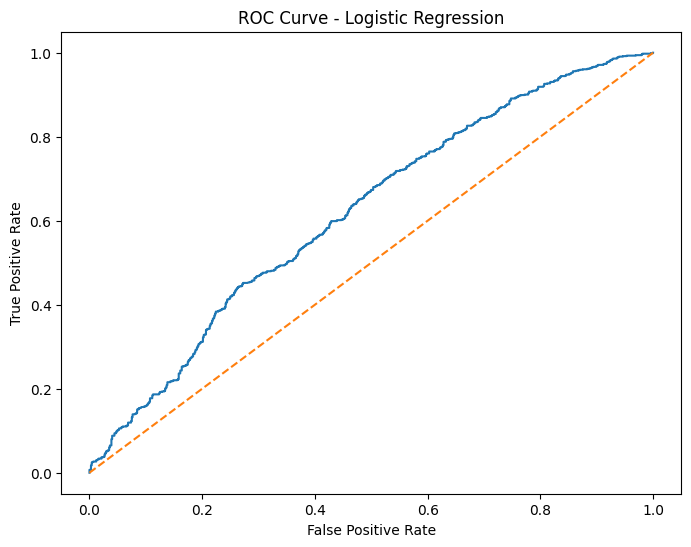

In [41]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')

plt.show()

## Decision Tree Model

A Decision Tree classifier was tested as a comparison model against the Logistic Regression baseline. Unlike Logistic Regression, Decision Trees can capture non-linear split-based patterns and do not require numeric feature scaling.

The initial Decision Tree model used one-hot encoding for categorical features and passed the numeric discharge feature through without scaling.

In [42]:
#from sklearn.compose import ColumnTransformer
#from sklearn.preprocessing import OneHotEncoder

#dec_processor = ColumnTransformer(transformers = [
    #('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical_features),
    #('num', 'passthrough', numeric_features) 
#])

## Decision Tree Accuracy and Overfitting Check

The default Decision Tree achieved approximately **56.1% test accuracy**, which was lower than the Logistic Regression model’s approximately **59.1% test accuracy**.

To check for overfitting, training accuracy was also evaluated. The Decision Tree achieved approximately **97.4% training accuracy**, creating a large gap between training and testing performance. This indicates severe overfitting: the model learned training-specific patterns that did not generalize well to unseen hospital-measure records.

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

dec_processor = ColumnTransformer(transformers = [
    ('cat', OrdinalEncoder(handle_unknown= 'use_encoded_value', unknown_value = -1), categorical_features),
    ('num', 'passthrough', numeric_features) 
])

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dec_tree_pipeline = Pipeline(steps = [
    ('preprocessor', dec_processor),
    ('model', DecisionTreeClassifier(max_depth = 5, 
                                     random_state = 42))
])

dec_tree_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [45]:
y_dec_pred = dec_tree_pipeline.predict(X_test)

y_dec_pred_prob = dec_tree_pipeline.predict_proba(X_test)[:, 1] 

In [46]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_dec_pred)

0.5789800995024875

In [47]:
from sklearn.metrics import confusion_matrix 

confusion_matrix(y_test, y_dec_pred)

array([[209, 536],
       [141, 722]])

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_score(y_test, y_dec_pred)

recall_score(y_test, y_dec_pred)

f1_score(y_test, y_dec_pred)

0.6808109382366808

In [51]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_dec_pred_prob)

0.6062401331394309

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_dec_pred))

              precision    recall  f1-score   support

           0       0.60      0.28      0.38       745
           1       0.57      0.84      0.68       863

    accuracy                           0.58      1608
   macro avg       0.59      0.56      0.53      1608
weighted avg       0.58      0.58      0.54      1608



## Model Comparison

Both Logistic Regression and Decision Tree classifiers were evaluated using the same train-test split and healthcare-focused feature set.

### Logistic Regression

The Logistic Regression model achieved:
- approximately **59.1% accuracy**
- approximately **0.67 F1-score**
- approximately **0.62 ROC-AUC**

The model provided slightly higher overall accuracy and more balanced classification behavior. However, overall class separation ability remained limited, likely due to the restricted feature set and the dense ERR distribution around the classification threshold.

### Decision Tree

Several Decision Tree configurations were tested:
- default one-hot encoded tree
- constrained tree with reduced depth
- ordinal-encoded tree

The ordinal-encoded Decision Tree produced the strongest tree-based results:
- approximately **57.9% accuracy**
- approximately **0.68 F1-score**
- approximately **0.84 recall**
- approximately **0.61 ROC-AUC**

The Decision Tree achieved stronger positive-class recall than Logistic Regression but also produced substantially more false positives and weaker identification of non-high excess readmission records.

The unconstrained Decision Tree also demonstrated severe overfitting behavior:
- approximately **97.4% training accuracy**
- approximately **56.1% testing accuracy**

This large train-test performance gap indicates that the model memorized training-specific patterns that did not translate effectively to unseen hospital-measure records.

### Final Comparison Interpretation

The results demonstrate that model selection depends on which performance characteristics are prioritized.

- Logistic Regression provided slightly stronger overall accuracy, stronger overall ROC-AUC performance, and more stable generalization behavior.
- The ordinal-encoded Decision Tree produced stronger recall for high excess readmission records but at the cost of increased false positives and weaker performance for the non-high class.

Overall, Logistic Regression provided the strongest balance of interpretability, stability, and overall performance for this healthcare analytics classification task.

## Project Limitations

Several important limitations should be considered when interpreting this project.

### Collection of Public CMS Data
This project used publicly reported CMS HRRP hospital-measure data rather than patient-level clinical data. As a result, the model classifies hospital-measure records rather than predicting individual patient readmission risk.

### Limited Feature Set
The final modeling dataset intentionally used a smaller feature set:
- `state`
- `measure_name`
- `number_of_discharges`

Many potentially stronger predictors were intentionally excluded to avoid leakage or unrealistic modeling behavior.

### Leakage Prevention Constraints
Variables directly tied to the target calculation were excluded from modeling, including:
- `excess_readmission_ratio`
- `predicted_readmission_rate`
- `expected_readmission_rate`
- `number_of_readmissions`

While excluding these variables reduced predictive accuracy, it improved the defensibility of the results.

### Structurally Difficult Classification Boundary
The excess readmission ratio distribution was tightly concentrated around 1.0, meaning many observations were located near the classification threshold. This creates substantial overlap between the two target classes and limits achievable model performance.

### Structural Reporting Missingness
CMS reporting suppression rules created structurally missing values for some measures and hospitals. Rows missing the target variable were excluded from supervised modeling, reducing the available sample size to analyze.

## Final Modeling Conclusion

This project demonstrated a complete healthcare-focused predictive analytics workflow using publicly available CMS Hospital Readmissions Reduction Program data.

The workflow included:
- structural data validation
- missingness investigation
- leakage-aware feature selection
- binary target construction
- preprocessing pipelines
- classification model training
- evaluation and model comparison

The results showed that both Logistic Regression and Decision Tree models achieved only modest predictive performance, which is consistent with the limited feature set and the difficult classification boundary near an excess readmission ratio of 1.0.

Among the evaluated models:
- Logistic Regression provided slightly stronger overall accuracy, ROC-AUC performance, and stabler behavior.
- The ordinal-encoded Decision Tree achieved stronger recall, but it comes with increased false positives and weak performance for the lower class.

Overall, the project demonstrates an understanding of:
- healthcare analytics framing
- supervised classification workflows
- preprocessing pipelines
- model evaluation metrics
- overfitting detection
- leakage prevention
- realistic interpretation of predictive modeling results

All in all, this project was intentionally framed as a hospital-measure-level healthcare analytics classification task rather than an unrealistic patient-level clinical prediction system.